# GPT-2 Training Replication Notebook

This notebook mainly adopted from
[https://github.com/karpathy/nanoGPT/tree/master](https://github.com/karpathy/nanoGPT/tree/master).

| Model | Date | Blog | Paper |
|-------|------|------|-------|
| GPT-1 | June 2018 | [Improving Language Understanding with Unsupervised Learning](https://openai.com/index/language-unsupervised/) | [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf) |
| GPT-2 | February 2019 | [Better Language Models and Their Implications](https://openai.com/index/better-language-models/) | [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) |
| GPT-3 | May 2020 | [Language Models are Few-Shot Learners](https://openai.com/index/language-models-are-few-shot-learners/) | [Language Models are Few-Shot Learners](https://arxiv.org/pdf/2005.14165) |
| GPT-4 | March 2023 | [GPT-4](https://openai.com/index/gpt-4/) · [GPT-4 Research](https://openai.com/index/gpt-4-research/) | [GPT-4 Technical Report](https://arxiv.org/abs/2303.08774) |
| GPT-5 | August 2025 | [Introducing GPT-5](https://openai.com/index/introducing-gpt-5/) | [GPT-5 Technical Report](https://arxiv.org/abs/2601.03267) |

## 1. AR-LLMs (GPT-2) Generation

- In this jupyter notebook, we will train a GPT-2 model. Before we go, let us see the well-trained GPT-2 from OpenAI and check how to generate new sentences from it. Please figure it by yourself using uv to configure your own env.

In [2]:
import os
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore")

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
# change it to your local folder if you are not using qz.cfff platform.
os.environ["HF_HOME"] = "/inspire/hdd/project/fdu-aidake-cfff/public/hf-home"
print(os.environ.get("HF_ENDPOINT"))

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import time

jnk_start_time = time.time()

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("gpt2") 
# add the EOS token as PAD token to avoid warnings
model = AutoModelForCausalLM.from_pretrained(
    "gpt2", 
    pad_token_id=tokenizer.eos_token_id
).to(device)
print(model) # this gives you the model architecture and parameters.

https://hf-mirror.com


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [3]:
from torchinfo import summary

print("Generating model summary...")
summary(
    model, 
    input_size=(10, 128), 
    dtypes=[torch.long],  # CRITICAL: GPT-2 expects integers for token IDs, not floats
    device=device,
    col_names=("input_size", "output_size", "num_params", "params_percent")
)

Generating model summary...


Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Param %
GPT2LMHeadModel                                    [10, 128]                 --                        --                        -23.67%
├─GPT2Model: 1-1                                   [10, 128]                 --                        --                             --
│    └─Embedding: 2-1                              [10, 128]                 [10, 128, 768]            38,597,376                 23.67%
│    └─Embedding: 2-2                              [1, 128]                  [1, 128, 768]             786,432                     0.48%
│    └─Dropout: 2-3                                [10, 128, 768]            [10, 128, 768]            --                             --
│    └─ModuleList: 2-4                             --                        --                        --                             --
│    │    └─GPT2Block: 3-1               

### 1.1 Greedy Search

In [4]:
# encode context the generation is conditioned on
prompt = 'I enjoy walking with my cute dog'
model_inputs = tokenizer(prompt, return_tensors='pt').to(device)
print(model_inputs)
print(tokenizer.eos_token_id) # <|endoftext|>

# generate 40 new tokens
greedy_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    pad_token_id=tokenizer.eos_token_id
    )
print("Output: " + tokenizer.decode(greedy_output[0], skip_special_tokens=True))

{'input_ids': tensor([[   40,  2883,  6155,   351,   616, 13779,  3290]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}
50256
Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my dog.

I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my dog.

I'm not sure if I'll ever be able to walk with my dog. I'm not sure if I'll ever be able to walk with my


**Hugging face use Greedy search by default. The output looks like repeating itself.**

### 1.2 Beam Search

In [5]:
# activate beam search and early_stopping
beam_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    num_beams=5,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)
print("Output: " + tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever


**Beam search try to avoid local optima but still, the output looks like repeating itself.**

### 1.3 Beam Search with N-gram

In [6]:
# set no_repeat_ngram_size to 2
beam_output = model.generate(
    **model_inputs,
    max_new_tokens=100,
    num_beams=5,
    no_repeat_ngram_size=2,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time for me to take a step back and think about what I want to do next. I've always wanted to be a writer, so I thought I'd share my thoughts on how I would go about writing a book about my love of writing. Here are some of my favorite quotes from the book, as well as


**It seems that beam search with n-gram can avoid repeats. You can also generate multiple setencens as follows:**

In [7]:
# set return_num_sequences > 1
beam_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    num_beams=5,
    no_repeat_ngram_size=2,
    num_return_sequences=3,
    early_stopping=True,
    pad_token_id=tokenizer.eos_token_id
)

# now we have 3 output sequences
print("Output: ")
for i, beam_output in enumerate(beam_outputs):
    print("{}: {}".format(i, tokenizer.decode(beam_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's time for me to
--
1: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with her again.

I've been thinking about this for a while now, and I think it's time for me to
--
2: I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been thinking about this for a while now, and I think it's a good idea to
--


### 1.4 Pure Sampling (Standard Sampling)

In [8]:
# set seed to reproduce results. Feel free to change the seed though to get different results
from transformers import set_seed
set_seed(17)

# activate sampling and deactivate top_k by setting top_k = 0
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=0, # the model is no longer picking the single best word (greedy decoding)
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " +tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog here, and I have only one dog that uses me as guest pi in almost every hour. Ms. Elliott is a happy, vivacious dog like most of her friends," said marks.



### 1.5 Standard sampling with temprature

By adding `temperature=0.6` while keeping `top_k=0`, you are still allowing the model to sample from the entire token vocabulary, but you are mathematically altering the odds before the die is rolled.  Before a language model outputs probabilities, its final layer produces raw scores called **logits** ($z$). To convert these raw logits into a proper probability distribution that sums to 1, the model passes them through a Softmax function. Temperature ($T$) is a divisor applied directly to those logits *before* the Softmax is calculated: $p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$.

In [9]:
# use temperature to decrease the sensitivity to low probability candidates
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=0,
    temperature=0.6,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog, and I love playing with him. So, I think I'd like to get some of those things to work with me on the ground. I'm going to do the basics of balancing and building


### 1.6 Top-k Sampling

In [10]:
# set top_k to 50
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    pad_token_id=tokenizer.eos_token_id
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(sample_output[0], skip_special_tokens=True))


Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog with me in the backyard," she said.

She noted a few years ago that it would also be a hassle for anyone approaching someone who was looking for a pet, and wondered whether the community


### 1.7 Top-k Sampling with temprature

In [11]:
# use temperature to decrease the sensitivity to low probability candidates
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    temperature=0.6,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog and taking him to the park, but I also love walking with my dog. I love to walk with my dog, but I also love taking him to the park. I'm a big fan of


### 1.8 Top-p (nucleus) sampling

In [12]:
# set top_k to 50
sample_output = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_p=0.92,
    top_k=0,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: " + tokenizer.decode(sample_output[0], skip_special_tokens=True))

Output: I enjoy walking with my cute dog and putting her out for an evening in Europe and finding really good work. It was really worth it for her to do so much work and I'll be damned if I didn't like it".



In [13]:
# set top_k = 50 and set top_p = 0.95 and num_return_sequences = 3
sample_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    num_return_sequences=3,
    pad_token_id=tokenizer.eos_token_id
)

print("Output: ")

for i, sample_output in enumerate(sample_outputs):
    print("{}: {}".format(i, tokenizer.decode(sample_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog for a year or more, but lately, I've been thinking about taking a little extra time off for me and my pup to go to yoga and have fun together.

Today I was so
--
1: I enjoy walking with my cute dog, but we are also very open minded. Our dog is my pet, so I need to have it more that others can use me. If I can do a dog show, I could show my
--
2: I enjoy walking with my cute dog.

My husband is a very helpful dog lover. He loves to take care of me and always wants me to do it for him. The fact that he doesn't need to be around me
--


### 1.9 Most practical use

In [14]:
sample_outputs = model.generate(
    **model_inputs,
    max_new_tokens=40,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    temperature=0.7,             # Highly recommended for GPT models
    num_return_sequences=3,
    pad_token_id=tokenizer.eos_token_id,
    repetition_penalty=1.2       # Optional: Prevents the model from getting stuck in a loop
)
print("Output: ")

for i, sample_output in enumerate(sample_outputs):
    print("{}: {}".format(i, tokenizer.decode(sample_output, skip_special_tokens=True)))
    print('--')

Output: 
0: I enjoy walking with my cute dog and I will never let her down. My wife was so upset when she found out that we were having sex because of a problem they had done to our dogs, but now the bad news is it
--
1: I enjoy walking with my cute dog, but when I got home from work it was only because the house had a lot of space to move around. The second floor is where we have our office and now there are two rooms for us
--
2: I enjoy walking with my cute dog, but it is important to remember that all of us are part of the same family. I have always believed in keeping a good home and will continue doing so for as long as we can."

--


## 2. Try to replicate GPT2 from scratch

### 2.1 Check Transformer model and GPT-2 model

Loaded the pretrained GPT-2 model from the Hugging Face transformers. The original code of GPT-2 and its models are written in Tensorflow, which is not popular any more. We would like to choose to use Huggingface Transformers.

- [https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py](https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py)
- [https://huggingface.co/openai-community/gpt2](https://huggingface.co/openai-community/gpt2)

In [15]:
from transformers import GPT2LMHeadModel
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 
sd_hf = model_hf.state_dict()
for k, v in sd_hf.items():
    print(k, v.shape)
print(sd_hf['transformer.wpe.weight'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

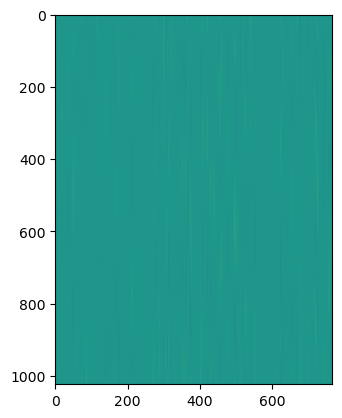

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline
# positional encoding for the first token
plt.imshow(sd_hf['transformer.wpe.weight'])
plt.show()

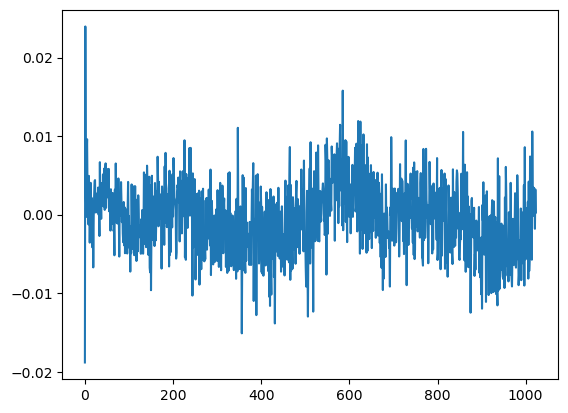

In [17]:
# positional encoding for the first token
plt.plot(sd_hf['transformer.wpe.weight'][:, 0])
plt.show()

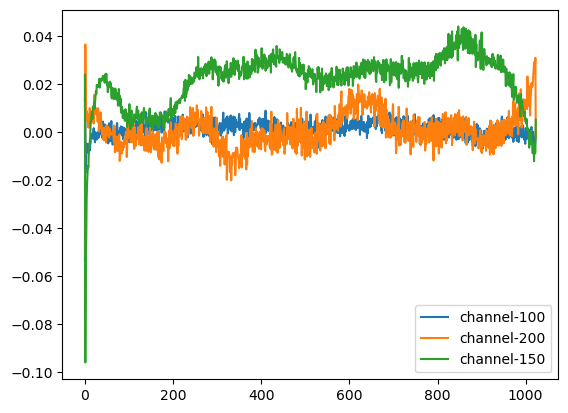

In [18]:
plt.plot(sd_hf['transformer.wpe.weight'][:, 100], label='channel-100')
plt.plot(sd_hf['transformer.wpe.weight'][:, 200], label='channel-200')
plt.plot(sd_hf['transformer.wpe.weight'][:, 250], label='channel-150')
plt.legend()
plt.show()

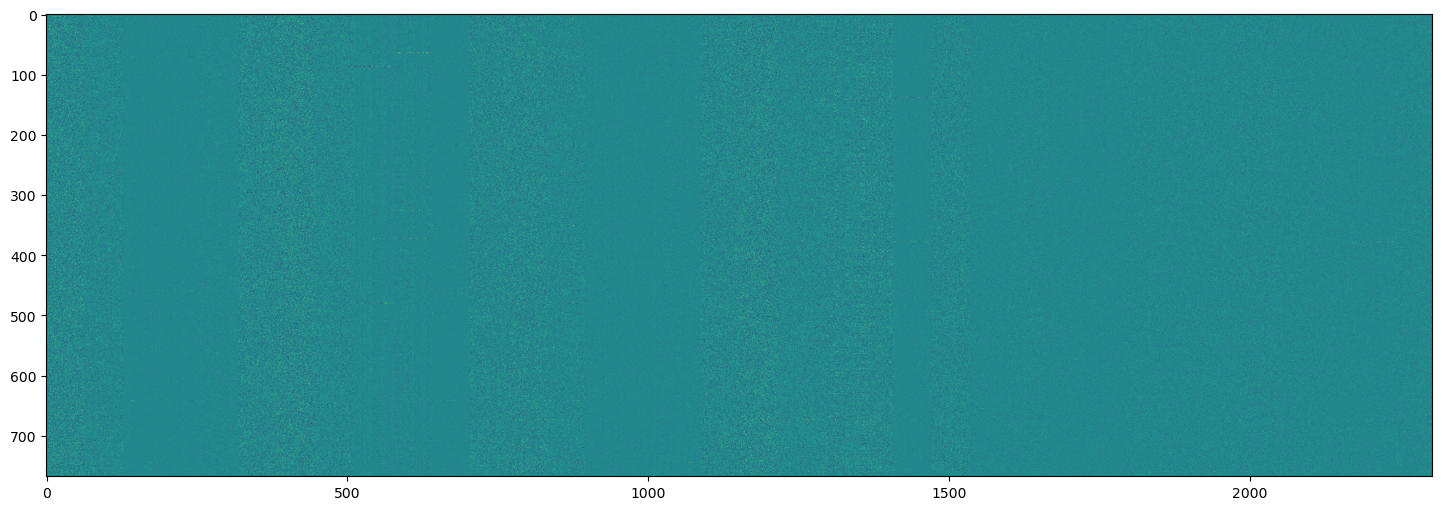

In [19]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"])
plt.show()

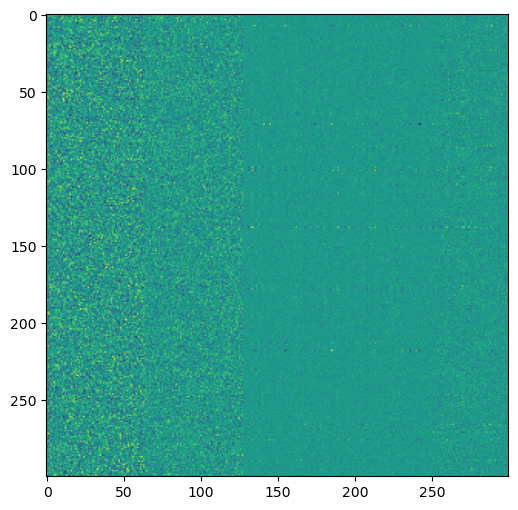

In [20]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300])
plt.show()

**generating sentence from GPT-2 model.**

In [21]:
from transformers import AutoModel
from transformers import pipeline, set_seed

set_seed(17)
# 1. Just load the pipeline. It will handle loading the model & tokenizer automatically.
generator = pipeline('text-generation', model='gpt2')
# 2. Pass the RAW string to the generator.
output = generator(
    "I love Fudan,", 
    max_new_tokens=50,    # How many words to add
    truncation=True,      # Cleanly handle long inputs
    pad_token_id=50256    # Stops the "Setting pad_token_id" warning
)
for i, o in enumerate(output):
    print(f"[{i}] {o['generated_text']}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[0] I love Fudan, and I love the fact that I could be the most important person ever to the world! When I was a kid, I really didn't know what I was doing. All I knew was that I was going to be an astronaut, and that I


GPT-2 architecture:

- GPT class ([nn.ModuleDict](https://pytorch.org/docs/stable/generated/torch.nn.ModuleDict.html), [nn.Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html), [nn.ModuleList](https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html), [nn.LayerNorm](https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html))
- Block class (CausalSelfAttention, LayerNorm, MLP)
- CausalSelfAttention class (Dropout, nn.Linear)
- MLP class (nn.Linear, nn.GELU, nn.Dropout)

**Please check GPT-2 v1 code**

### 3.2 Load GPT-2 from source code

In [22]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

In [23]:
class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

In [24]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        # This line creates a lower triangular attention mask (often called a causal mask) 
        # and registers it as a buffer inside your PyTorch model (not as a parameter).
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y

In [25]:
class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [26]:
@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

model= GPT.from_pretrained('gpt2')
print('Successfully load the model from GPT-2 to ours!')

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Successfully load the model from GPT-2 to ours!


### 3.3 Sampling from GTP-2 initial

- Adding forward for GPT class
- Add tiktoken for tokenization
- Top-k sampling algorithm

In [27]:
from transformers import GPT2LMHeadModel
# Choose your model_type, e.g., 'gpt2'
model_type = 'gpt2' 
model_hf = GPT2LMHeadModel.from_pretrained(model_type)
model_hf.save_pretrained(f"./{model_type}_weights")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [28]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(f"./{model_type}_weights")
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

In [30]:
num_return_sequences = 5
max_length = 30
model = GPT.from_pretrained('gpt2')
model.eval()

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [34]:
from transformers import GPT2Tokenizer
# Point it to your local directory
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'm a language model,")
print(tokens)
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
x = tokens


[15496, 11, 314, 1101, 257, 3303, 2746, 11]


In [36]:
import math 
# generate! right now x is (B, T) where B = 5, T = 8
# set the seed to 42
device = 'cpu'
torch.manual_seed(42)
# torch.cuda.manual_seed(42)
print(x.size(1), max_length)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        print(probs.shape, topk_probs.shape, topk_probs[0,:].sum())
        # select a token from the top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)
        print(x.shape)

for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = tokenizer.decode(tokens)
    print(">", decoded)

8 30
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8061)
torch.Size([5, 9])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.9104)
torch.Size([5, 10])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.5246)
torch.Size([5, 11])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8397)
torch.Size([5, 12])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8022)
torch.Size([5, 13])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8379)
torch.Size([5, 14])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.7881)
torch.Size([5, 15])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.4617)
torch.Size([5, 16])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.9095)
torch.Size([5, 17])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.9679)
torch.Size([5, 18])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8936)
torch.Size([5, 19])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.8956)
torch.Size([5, 20])
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.9402)
to

### 3.4 Sampling from random model

- We only need to change the code code from

```python
  model = GPT.from_pretrained('gpt2')
```
into
```python
  model = GPT(GPTConfig())
```

In [38]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to('cpu')
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")

tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
# x = tokens.to('cuda')
x = tokens.to('cpu')  # change to GPU, if you have any.

device = 'cpu'
torch.manual_seed(42)
# torch.cuda.manual_seed(42)
print(x.size(1), max_length)
while x.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        print(probs.shape, topk_probs.shape, topk_probs[0,:].sum())
        # select a token from the top-k probabilities
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

for i in range(num_return_sequences):
    tokens = x[i, :max_length].tolist()
    decoded = tokenizer.decode(tokens)
    print(">", decoded)


9 30
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0065)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0060)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0060)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0058)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0059)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0056)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0060)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0059)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0056)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0058)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0061)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0062)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0059)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0060)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0060)
torch.Size([5, 50257]) torch.Size([5, 50]) tensor(0.0059)
torch.Siz

## 3. Train GPT-2 model using Shakespeare dataset

In [39]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
data = text[:200]
print(data)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [40]:
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode(data)
print(tokens[:24])
buf = torch.tensor(tokens[:24])
x = buf.view(4, 6)
print(x)

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]
tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])


In [41]:
# data sample x and label y
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


### 3.1 Form a batch and put it into GPT-2 and then output logits

In [42]:
import math
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer


class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to(device)

import math
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
# x = tokens.to('cuda')
x = tokens.to(device)

print(f"using device: {device}")
with open('input.txt', 'r') as f:
    text = f.read()
text = text[:1000]
tokens = tokenizer.encode(text)
B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1])
x = buf[:-1].view(B, T).to(device)  # ← move to device
y = buf[1:].view(B, T).to(device)   # ← move to device
# get logits
model = GPT(GPTConfig())
model.to(device)
logits, loss = model(x)
print(logits.shape, loss)

logits, loss = model(x, y)
print(logits.shape, loss)

using device: mps
torch.Size([4, 32, 50257]) None
torch.Size([4, 32, 50257]) tensor(10.9805, device='mps:0', grad_fn=<NllLossBackward0>)


**get loss**

In [43]:
import numpy as np
print(np.log(1/50257.))

-10.82490511970208


### 3.2 Training the model via AdamW single batch

In [47]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

num_return_sequences = 5
max_length = 30
model = GPT(GPTConfig())
model.eval()
model.to('cpu')

import math
tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
tokens = tokenizer.encode("Hello, I'am a language model,")
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (5,8)
x = tokens.to('cpu')

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
device = "cpu" # OVERRIDE
with open('input.txt', 'r') as f:
    text = f.read()
text = text[:1000]
tokens = tokenizer.encode(text)
B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1])
buf = buf.to(device)
x = buf[:-1].view(B, T)
y = buf[1:].view(B, T)
# get logits
model = GPT(GPTConfig())
model.to(device)
logits, loss = model(x)
print(logits.shape, loss)

logits, loss = model(x, y)
print(logits.shape, loss)

# get logits
model = GPT(GPTConfig())
model.to(device)
# optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_hist = []
for i in range(50):
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"step {i}, loss: {loss.item()}")
    loss_hist.append(loss.item())

using device: mps
torch.Size([4, 32, 50257]) None
torch.Size([4, 32, 50257]) tensor(10.9772, grad_fn=<NllLossBackward0>)
step 0, loss: 10.92192554473877
step 1, loss: 6.678531169891357
step 2, loss: 4.539087295532227
step 3, loss: 2.810455560684204
step 4, loss: 1.66450035572052
step 5, loss: 0.9724115133285522
step 6, loss: 0.5524945259094238
step 7, loss: 0.32914838194847107
step 8, loss: 0.20630691945552826
step 9, loss: 0.1375797986984253
step 10, loss: 0.09169290214776993
step 11, loss: 0.06796441972255707
step 12, loss: 0.050717804580926895
step 13, loss: 0.03906472772359848
step 14, loss: 0.03328360617160797
step 15, loss: 0.02997284010052681
step 16, loss: 0.02612319216132164
step 17, loss: 0.021872038021683693
step 18, loss: 0.018497878685593605
step 19, loss: 0.01617106795310974
step 20, loss: 0.01454101875424385
step 21, loss: 0.01327988225966692
step 22, loss: 0.01216467097401619
step 23, loss: 0.011101818643510342
step 24, loss: 0.010102283209562302
step 25, loss: 0.009200

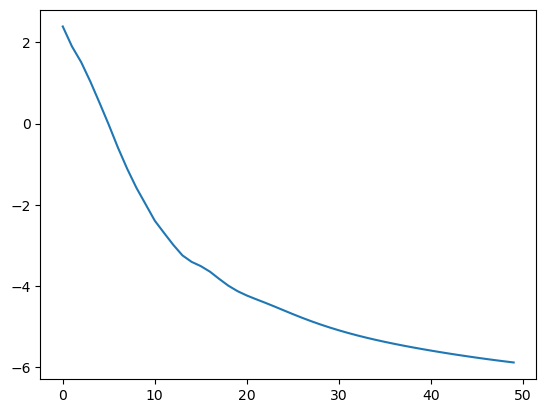

In [48]:
plt.plot(np.log(loss_hist))
plt.show()

**The model is overfitting the single batch!**

### 3.3 Embedding and Unembedding sharing

In [49]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [50]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [51]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

15521099731
15521099731


**[https://github.com/openai/gpt-2/blob/master/src/model.py embedding model line 154](https://github.com/openai/gpt-2/blob/master/src/model.py)**

**[https://github.com/openai/gpt-2/blob/master/src/model.py unembedding model line 171](https://github.com/openai/gpt-2/blob/master/src/model.py)**

In [52]:
from dataclasses import dataclass
import torch
import math
import torch.nn as nn
from torch.nn import functional as F
from transformers import GPT2Tokenizer


class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B
        self.T = T
        # at init load tokens from disk and store them in memory
        with open('input.txt', 'r') as f:
            text = f.read()
        tokenizer = GPT2Tokenizer.from_pretrained("./gpt2_weights")
        tokens = tokenizer.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"loaded {len(self.tokens)} tokens")
        print(f"1 epoch = {len(self.tokens) // (B * T)} batches")
        # state
        self.current_position = 0
        
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T+1]
        x = (buf[:-1]).view(B, T) # inputs
        y = (buf[1:]).view(B, T) # targets
        # advance the position in the tensor
        self.current_position += B * T
        # if loading the next batch would be out of bounds, reset
        if self.current_position + (B * T + 1) > len(self.tokens):
            self.current_position = 0
        return x, y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias) # matrix of W1
        # GELU paper: https://arxiv.org/pdf/1606.08415
        self.gelu    = nn.GELU() # nonlinear activation function
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias) # matrix of W2

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x
        
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    bias: bool = True
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),
                wpe = nn.Embedding(config.block_size, config.n_embd),
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f = nn.LayerNorm(config.n_embd),
            )
        )
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)


    def forward(self, idx, targets=None):
        b, t = idx.size() # (B, T)
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        """Loads pretrained GPT-2 model weights from huggingface. """
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

# attempt to autodetect the device
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

train_loader = DataLoaderLite(B=4, T=32)

# get logits
model = GPT(GPTConfig())
model.to(device)
# optimize!
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
hist_loss = []
for i in range(800):
    x, y = train_loader.next_batch()
    x, y = x.to(device), y.to(device)  # ← add this line
    optimizer.zero_grad()
    logits, loss = model(x, y)
    loss.backward()
    optimizer.step()
    print(f"step {i}, loss: {loss.item()}")
    hist_loss.append(loss.item())

using device: mps
loaded 338025 tokens
1 epoch = 2640 batches
step 0, loss: 11.202543258666992
step 1, loss: 9.705638885498047
step 2, loss: 8.997715950012207
step 3, loss: 9.35661506652832
step 4, loss: 8.936863899230957
step 5, loss: 8.41336441040039
step 6, loss: 9.085840225219727
step 7, loss: 8.794512748718262
step 8, loss: 8.156841278076172
step 9, loss: 8.047283172607422
step 10, loss: 8.351612091064453
step 11, loss: 7.557008743286133
step 12, loss: 7.903163909912109
step 13, loss: 7.477804183959961
step 14, loss: 7.566096305847168
step 15, loss: 7.370815277099609
step 16, loss: 7.454246520996094
step 17, loss: 8.2938814163208
step 18, loss: 7.206575393676758
step 19, loss: 7.785372734069824
step 20, loss: 7.479645729064941
step 21, loss: 7.782048225402832
step 22, loss: 6.46986722946167
step 23, loss: 6.846782684326172
step 24, loss: 6.821654796600342
step 25, loss: 6.707326889038086
step 26, loss: 6.777947902679443
step 27, loss: 7.661045074462891
step 28, loss: 7.22043275833

In [ ]:
plt.plot(hist_loss)
plt.show()

In [ ]:
!time python train_gpt2_multi_epoch.py

### 3.4 FlashAttention

**To speedup the multi head attention, one can apply [flash attention](https://arxiv.org/abs/2205.14135).**

In [ ]:
!time python train_gpt2_flash_attention.py

### 3.5 Dynamic Learning rate Schedule

In [ ]:
!time python train_gpt2_dynamic_lr.py

## 4. Train GPT-2 using fineweb-edu dataset

### 4.1 Loadset

- We will use [https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) for training a GPT-2 model.
- Paper [The FineWeb Datasets: Decanting the Web for the Finest Text Data at Scale](https://arxiv.org/pdf/2406.17557)
- **sample-10BT**: a subset randomly sampled from the whole dataset of around 10B gpt2 tokens
- **downloaded**: we already downloaded at global_public/datasets-models/lecture-06-gpts-edu_fineweb10B

### 4.2 Training GPT-2 on GPU

Then run the following command: ``` python train_gpt2.py ```
If the B=64 (batch size is too large, just let it be 32 or 16).

### 4.3 Evaluation on [HellaSWAG](https://arxiv.org/abs/1905.07830)

Run the following command:

```python
python hellaswag.py
```

In [53]:
# Finally, you all done! Please submit your jupyter notebook via elearning!
your_chinese_name = "王志昊" # put your chinese name here
your_student_id = "24307140070" # put your student id here

jnk_end_time = time.time()
total = jnk_end_time - jnk_start_time
h, rem = divmod(int(total), 3600)
m, s = divmod(rem, 60)

print(f"Total runtime: {h} h {m} min {s} s")
print(f"I am {your_chinese_name}:{your_student_id}, I am doing a great job!")

Total runtime: 0 h 8 min 43 s
I am 王志昊:24307140070, I am doing a great job!


- **save your work as html file.

In [55]:
!jupyter nbconvert lecture-06-gpts-24307140070-王志昊.ipynb --to html --template classic --embed-images

[NbConvertApp] Converting notebook lecture-06-gpts-24307140070-王志昊.ipynb to html
[NbConvertApp] Writing 607589 bytes to lecture-06-gpts-24307140070-王志昊.html
